In [1]:
import pandas as pd
import json
import matplotlib.pyplot as plt

In [2]:
def load_json_sample(file_path, n=100000):
    data = []
    with open(file_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if i >= n:
                break
            data.append(json.loads(line))
    return pd.DataFrame(data)

business = load_json_sample('./data/yelp_academic_dataset_business.json', n=50000)
review = load_json_sample('./data/yelp_academic_dataset_review.json', n=100000)

In [3]:

business_rest = business[business['categories'].str.contains('Restaurant', na=False)]

print("Number of resturants:", len(business_rest))

Number of resturants: 17318


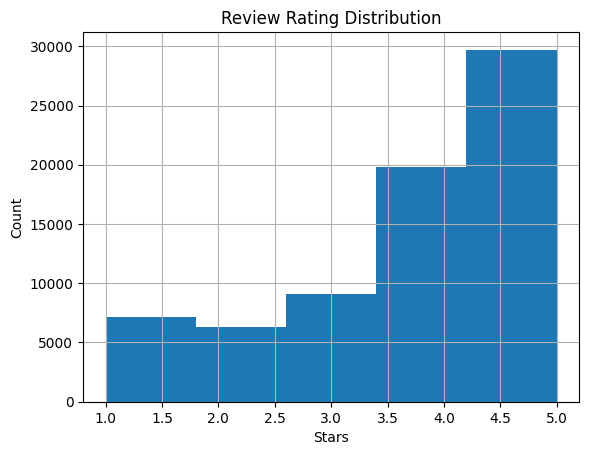

In [4]:
df = review.merge(business_rest[['business_id', 'city', 'stars']], on='business_id')

plt.figure()
df['stars_x'].hist(bins=5)
plt.title("Review Rating Distribution")
plt.xlabel("Stars")
plt.ylabel("Count")
plt.show()

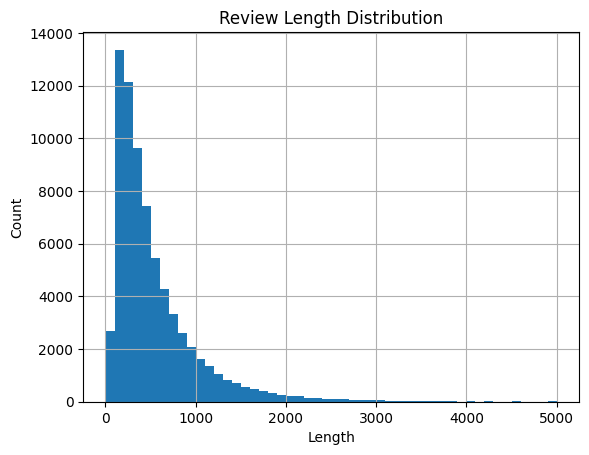

In [5]:
df['review_length'] = df['text'].apply(len)

plt.figure()
df['review_length'].hist(bins=50)
plt.title("Review Length Distribution")
plt.xlabel("Length")
plt.ylabel("Count")
plt.show()


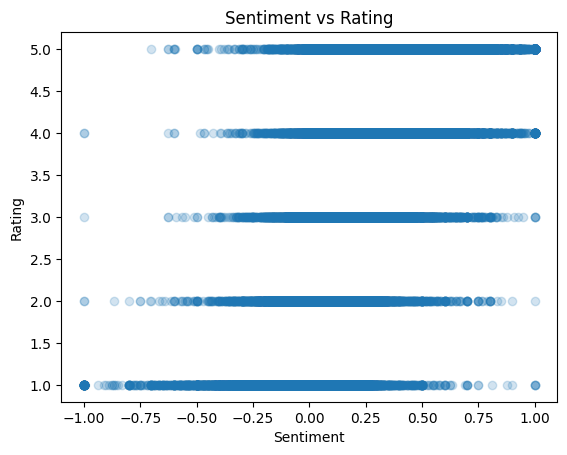

In [6]:
from textblob import TextBlob

def get_sentiment(text):
    return TextBlob(text).sentiment.polarity

df['sentiment'] = df['text'].apply(get_sentiment)

plt.figure()
plt.scatter(df['sentiment'], df['stars_x'], alpha=0.2)
plt.title("Sentiment vs Rating")
plt.xlabel("Sentiment")
plt.ylabel("Rating")
plt.show()

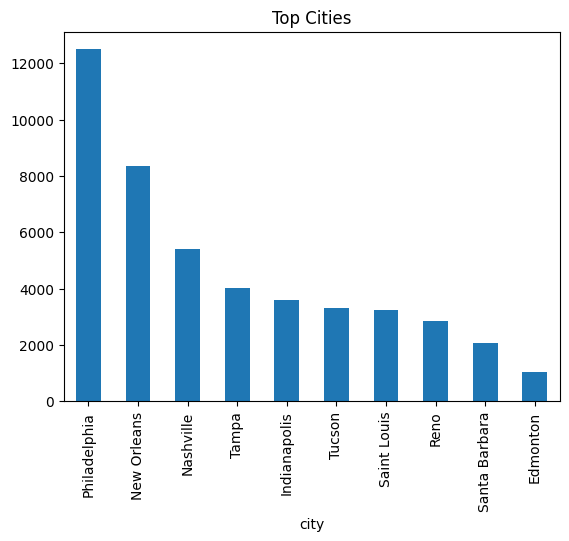

In [7]:
top_cities = df['city'].value_counts().head(10)

plt.figure()
top_cities.plot(kind='bar')
plt.title("Top Cities")
plt.show()

In [8]:
print(df[['sentiment', 'stars_x', 'review_length']].corr())

               sentiment   stars_x  review_length
sentiment       1.000000  0.607567      -0.228223
stars_x         0.607567  1.000000      -0.156266
review_length  -0.228223 -0.156266       1.000000


In [9]:
# 1. Text Preprocessing

import re
from sklearn.feature_extraction.text import CountVectorizer

def clean_text(text):
    """
    Basic text cleaning:
    - Lowercase
    - Remove punctuation
    - Remove numbers
    """
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['clean_text'] = df['text'].apply(clean_text)

# 2. Vectorization

vectorizer = CountVectorizer(
    max_df=0.9,        # ignore very frequent words
    min_df=10,         # ignore rare words
    stop_words='english'
)

X = vectorizer.fit_transform(df['clean_text'])


In [ ]:
# LDA Model

from sklearn.decomposition import LatentDirichletAllocation

n_topics = 5

lda = LatentDirichletAllocation(
    n_components=n_topics,
    random_state=42
)

lda.fit(X)

# Display Topics

def print_topics(model, feature_names, n_top_words=10):
    for idx, topic in enumerate(model.components_):
        print(f"\nTopic {idx}:")
        print(" ".join([feature_names[i] 
                        for i in topic.argsort()[-n_top_words:]]))

feature_names = vectorizer.get_feature_names_out()
print_topics(lda, feature_names)


In [ ]:
# Topic Distribution per Review
topic_distribution = lda.transform(X)

# Add dominant topic to dataframe
df['dominant_topic'] = topic_distribution.argmax(axis=1)

# Topic Distribution Summary
topic_counts = df['dominant_topic'].value_counts()
print("\nTopic Distribution:")
print(topic_counts)

# Topic vs Rating

topic_rating = df.groupby('dominant_topic')['stars_x'].mean()

print("\nAverage Rating per Topic:")
print(topic_rating)

# Save Results
topic_rating.to_csv("topic_rating.csv")
topic_counts.to_csv("topic_counts.csv")


Topic Distribution:
dominant_topic
2    22140
1    14305
0    12981
3    11734
4    10965
Name: count, dtype: int64

Average Rating per Topic:
dominant_topic
0    3.699792
1    4.548759
2    4.245845
3    2.931822
4    3.041860
Name: stars_x, dtype: float64


In [14]:
# Enhanced text cleaning with lemmatisation and custom stop‑word removal

import re
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords

# Download required resources (only once)
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('stopwords')

# Custom stop words that frequently appear across all topics and blur distinctions
custom_stop_words = set([
    'good', 'great', 'place', 'food', 'like', 'just', 'also', 'really',
    'get', 'got', 'even', 'well', 'still', 'restaurant', 'time', 'back',
    'one', 'would', 'always', 'go', 'come', 'came', 'try', 'tried'
])

stop_words = set(stopwords.words('english'))
stop_words.update(custom_stop_words)

lemmatizer = WordNetLemmatizer()

def lemmatize_and_clean(text):
    # Lowercase and remove numbers / punctuation
    text = re.sub(r'[^\w\s]', '', text.lower())
    tokens = nltk.word_tokenize(text)
    # Lemmatise and keep only alphabetic tokens not in stop words
    clean_tokens = [
        lemmatizer.lemmatize(tok) for tok in tokens
        if tok.isalpha() and tok not in stop_words
    ]
    return ' '.join(clean_tokens)

# Apply the improved cleaning to the original review text
df['clean_text_advanced'] = df['text'].apply(lemmatize_and_clean)

# Compare length before and after
df['adv_length'] = df['clean_text_advanced'].apply(lambda x: len(x.split()))
print("Original average length:", df['review_length'].mean())
print("Advanced clean average length:", df['adv_length'].mean())

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\qym20\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\qym20\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\qym20\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Original average length: 537.3172409012132
Advanced clean average length: 44.44185788561525


In [ ]:
# Vectorisation with TF‑IDF and comparison of topic numbers

from sklearn.feature_extraction.text import TfidfVectorizer

# TF‑IDF vectorizer with the same df thresholds but on the advanced clean text
tfidf_vectorizer = TfidfVectorizer(
    max_df=0.8,             # ignore terms appearing in >80% of docs (very generic)
    min_df=5,               # ignore terms appearing in <5 docs (too rare)
    stop_words='english'
)

# Create document‑term matrix from the advanced cleaned text
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text_advanced'])
print("TF-IDF matrix shape:", X_tfidf.shape)

# Define candidate topic numbers and store perplexity
candidate_topics = [3, 5, 7, 10, 12]
perplexities = []

for n in candidate_topics:
    lda = LatentDirichletAllocation(n_components=n, random_state=42, max_iter=10,
                                    learning_method='online', batch_size=128)
    lda.fit(X_tfidf)
    perplexities.append(lda.perplexity(X_tfidf))
    print(f"Topics={n}, Perplexity={lda.perplexity(X_tfidf):.2f}")

plt.figure()
plt.plot(candidate_topics, perplexities, marker='o')
plt.xlabel('Number of Topics')
plt.ylabel('Perplexity')
plt.title('Topic Model Perplexity vs Number of Topics')
plt.show()

In [17]:
# Train the final LDA model with the chosen number of topics

best_n = 7

lda_tfidf = LatentDirichletAllocation(
    n_components=best_n,
    random_state=42,
    max_iter=15,
    learning_method='online',
    batch_size=128
)
lda_tfidf.fit(X_tfidf)

# Extract top words for each topic
def display_topics(model, feature_names, n_top_words=12):
    topics = {}
    for idx, topic in enumerate(model.components_):
        top_indices = topic.argsort()[-n_top_words:][::-1]
        top_words = [feature_names[i] for i in top_indices]
        topics[idx] = top_words
        print(f"Topic {idx}: {' | '.join(top_words)}")
    return topics

tfidf_feature_names = tfidf_vectorizer.get_feature_names_out()
topic_words = display_topics(lda_tfidf, tfidf_feature_names)

Topic 0: hotel | gyro | room | relaxed | cheesecake | greek | cupcake | annoying | coworker | maple | desk | ale
Topic 1: beignet | crepe | dan | website | lighting | indianapolis | stl | desired | impeccable | funky | subway | chinatown
Topic 2: chicken | delicious | sushi | best | taco | fresh | love | service | roll | amazing | sauce | rice
Topic 3: prime | downside | oyster | doughnut | coke | basket | cheesesteaks | cent | boiled | dined | luke | comfy
Topic 4: min | poor | hibachi | milkshake | sushi | rude | tonight | zero | anniversary | manager | coupon | ignored
Topic 5: service | pizza | order | nice | burger | drink | staff | table | ordered | bar | menu | dont
Topic 6: sangria | tour | flatbread | empanadas | quiche | chaat | cider | los | habit | grandma | bottomless | trap


Average Rating and Count by Experience Factor:
                                             mean  count
experience_factor                                       
Food Quality (Multi-Cuisine Excellence)  4.325409  16321
Drinks & Social Dining                   4.296296     54
Value                                    4.285714      7
Local Flavors & Ambiance                 4.117647     17
Hotel Dining & Mixed Experience          4.041667     24
Standard Service & Casual Dining         3.660426  55658
Poor Service & Negative Experience       2.272727     44


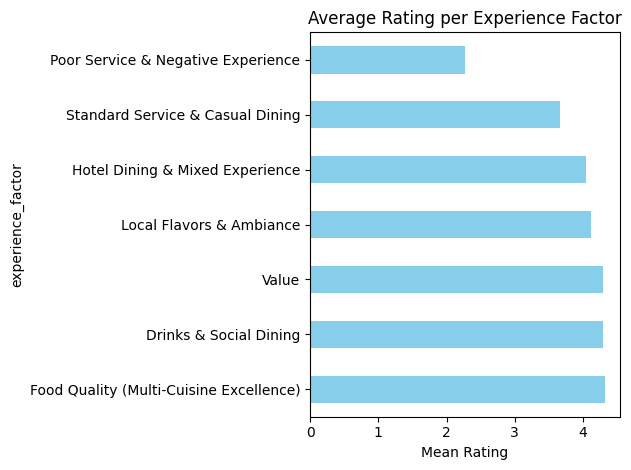

In [18]:
# Assign experience labels to topics and examine average rating per topic

topic_dist_adv = lda_tfidf.transform(X_tfidf)
df['dominant_topic_adv'] = topic_dist_adv.argmax(axis=1)

# Manual mapping based on top words (adjust after inspecting topic_words)
topic_label_map = {
    0: 'Hotel Dining & Mixed Experience',
    1: 'Local Flavors & Ambiance',
    2: 'Food Quality (Multi-Cuisine Excellence)',
    3: 'Value',
    4: 'Poor Service & Negative Experience',
    5: 'Standard Service & Casual Dining',
    6: 'Drinks & Social Dining'
}
df['experience_factor'] = df['dominant_topic_adv'].map(topic_label_map)

# Average rating per experience factor
factor_rating = df.groupby('experience_factor')['stars_x'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("Average Rating and Count by Experience Factor:")
print(factor_rating)

# Plot for visual inspection
factor_rating['mean'].plot(kind='barh', color='skyblue')
plt.title('Average Rating per Experience Factor')
plt.xlabel('Mean Rating')
plt.tight_layout()
plt.show()

Training R²: 0.45569591671023346
Test R²: 0.46173553706275994

Feature contributions (standardised):
          Feature  Coefficient
7       sentiment     0.657194
9  business_stars     0.314583
2         topic_2     0.076135
6         topic_6     0.021236
0         topic_0     0.010374
1         topic_1     0.006626
3         topic_3    -0.015146
8   review_length    -0.030608
5         topic_5    -0.051459
4         topic_4    -0.155717


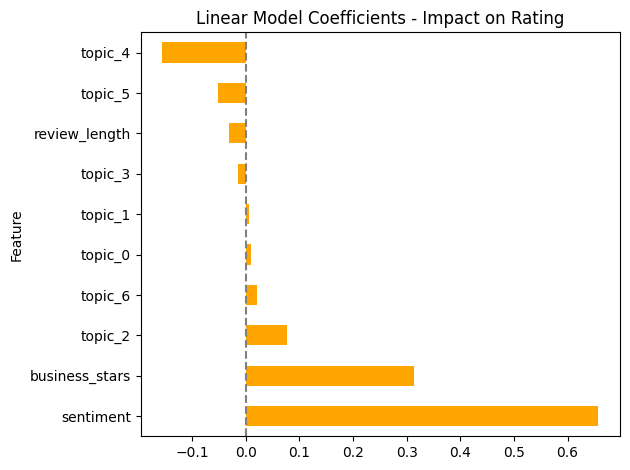

In [19]:
# Build a simple linear regression model to predict rating
# using topic probabilities, sentiment, and review length.

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Create feature matrix: topic probabilities + sentiment + review_length + business_stars
feature_cols = [f'topic_{i}' for i in range(best_n)]
topic_prob_df = pd.DataFrame(topic_dist_adv, columns=feature_cols)

# Add other features
topic_prob_df['sentiment'] = df['sentiment'].values
topic_prob_df['review_length'] = df['review_length'].values
topic_prob_df['business_stars'] = df['stars_y'].values

y = df['stars_x'].values

X_train, X_test, y_train, y_test = train_test_split(
    topic_prob_df, y, test_size=0.2, random_state=42
)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train linear regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
print("Training R²:", lr.score(X_train_scaled, y_train))
print("Test R²:", lr.score(X_test_scaled, y_test))

# Display coefficients as explanation
coeff_df = pd.DataFrame({
    'Feature': topic_prob_df.columns,
    'Coefficient': lr.coef_
}).sort_values('Coefficient', ascending=False)

print("\nFeature contributions (standardised):")
print(coeff_df)

# Visualise the coefficients
coeff_df.set_index('Feature')['Coefficient'].plot(kind='barh', color='orange')
plt.title('Linear Model Coefficients - Impact on Rating')
plt.axvline(0, color='grey', linestyle='--')
plt.tight_layout()
plt.show()

In [20]:
# class‑weighted regression

from sklearn.utils.class_weight import compute_sample_weight

# Compute sample weights based on rating (treat rating as approximate class)
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train.round().astype(int))

# Re‑train the linear model with sample weights
lr_weighted = LinearRegression()
lr_weighted.fit(X_train_scaled, y_train, sample_weight=sample_weights)
print("Weighted Training R²:", lr_weighted.score(X_train_scaled, y_train))
print("Weighted Test R²:", lr_weighted.score(X_test_scaled, y_test))

# Compare coefficients
coeff_weighted = pd.DataFrame({
    'Feature': topic_prob_df.columns,
    'Coefficient (weighted)': lr_weighted.coef_
}).sort_values('Coefficient (weighted)', ascending=False)
print(coeff_weighted)

Weighted Training R²: 0.3471797469000756
Weighted Test R²: 0.3523283005258584
          Feature  Coefficient (weighted)
7       sentiment                0.709532
9  business_stars                0.270324
2         topic_2                0.100280
6         topic_6                0.028785
0         topic_0                0.015554
1         topic_1                0.013793
3         topic_3               -0.015387
8   review_length               -0.054714
5         topic_5               -0.081040
4         topic_4               -0.137737


In [21]:
# Model Performance by User Activity Group

from sklearn.metrics import mean_absolute_error, r2_score
import numpy as np

# Calculate user activity
user_counts = df['user_id'].value_counts()
df['user_activity'] = df['user_id'].map(user_counts)

# low (1‑2 reviews), medium (3‑5), high (6+)
bins = [0, 2, 5, np.inf]
labels = ['Low (1-2)', 'Medium (3-5)', 'High (6+)']
df['activity_group'] = pd.cut(df['user_activity'], bins=bins, labels=labels)

# Add the corresponding activity group for test rows.
test_indices = X_test.index
activity_test = df.loc[test_indices, 'activity_group']
y_pred_lr = lr.predict(X_test_scaled)

print("Model performance across user activity groups (test set):")
for group in labels:
    mask = activity_test == group
    if mask.sum() == 0:
        continue
    y_true_group = y_test[mask]
    y_pred_group = y_pred_lr[mask]
    mae = mean_absolute_error(y_true_group, y_pred_group)
    r2 = r2_score(y_true_group, y_pred_group)
    print(f"{group}: n={mask.sum():4d}  MAE={mae:.3f}  R²={r2:.3f}")

Model performance across user activity groups (test set):
Low (1-2): n=12426  MAE=0.789  R²=0.480
Medium (3-5): n=1455  MAE=0.747  R²=0.290
High (6+): n= 544  MAE=0.682  R²=0.251


In [22]:
# Given a single review, reconstruct its topic distribution,
# predict the rating with the linear model, and output a human‑readable
# explanation showing which experience factors contributed most (positively or negatively).

def explain_review(review_index, df, lda_model, vectorizer, lr_model, scaler,
                   topic_label_map, topic_words_map):
    print(f"\n--- Review (index {review_index}) ---")
    review = df.iloc[review_index]
    text_clean = review['clean_text_advanced']
    print(review.text)
    
    # Get topic distribution for this review
    vec = vectorizer.transform([text_clean])
    topic_probs = lda_model.transform(vec)[0]
    
    # Build feature vector (same order as training)
    features = {f'topic_{i}': prob for i, prob in enumerate(topic_probs)}
    features['sentiment'] = review['sentiment']
    features['review_length'] = review['review_length']
    features['business_stars'] = review['stars_y']
    
    feature_df = pd.DataFrame([features])
    feature_scaled = scaler.transform(feature_df)
    predicted_rating = lr_model.predict(feature_scaled)[0]
    actual_rating = review['stars_x']
    
    # Calculate each feature's contribution (coefficient * standardised value)
    contrib = feature_scaled[0] * lr_model.coef_
    contrib_dict = dict(zip(feature_df.columns, contrib))
    
    # Sort topics by absolute contribution for explanation
    sorted_contrib = sorted(contrib_dict.items(), key=lambda x: abs(x[1]), reverse=True)
    
    # Build explanation sentences
    print(f"\n--- Review Explanation (index {review_index}) ---")
    sentences = []
    for feat, val in sorted_contrib:
        if not feat.startswith('topic_'):
            continue
        topic_idx = int(feat.split('_')[1])
        factor = topic_label_map.get(topic_idx, f"Topic {topic_idx}")
        direction = "positive" if val > 0 else "negative"
        sentences.append(
            f"The experience factor **{factor}** had a {direction} contribution "
            f"(weighted value: {val:.3f})."
        )
    
    # Add sentiment and business stars explanation
    if contrib_dict['sentiment'] > 0:
        sentences.append("Overall positive sentiment.")
    else:
        sentences.append("Overall negative sentiment.")
    
    print(f"Actual rating: {actual_rating}")
    print(f"Predicted rating: {predicted_rating:.2f}")
    print("Why this prediction?")
    for s in sentences:
        print(s)
    
    # Optionally print top topic words
    dom_topic = np.argmax(topic_probs)
    print(f"\nDominant experience factor: {topic_label_map.get(dom_topic, dom_topic)}")
    print("Top words in this topic:", topic_words_map[dom_topic][:8])

# Prepare topic words map
topic_words_map = {i: words for i, words in topic_words.items()}

explain_review(43, df, lda_tfidf, tfidf_vectorizer, lr, scaler, topic_label_map, topic_words_map)
explain_review(53, df, lda_tfidf, tfidf_vectorizer, lr, scaler, topic_label_map, topic_words_map)


--- Review (index 43) ---
My go-to spot on a Saturday night! I was real bummed that lucys closed, but was pleasantly surprised by this bar just across the street!
Their food is better than expected. I always get wings and fries. (be careful of the wtf sauce though) Sometimes it takes a real long time to get the bartenders attention, but the place is usually packed. And if you're lucky the always sunny crew will pop in!

--- Review Explanation (index 43) ---
Actual rating: 4.0
Predicted rating: 3.17
Why this prediction?
The experience factor **Food Quality (Multi-Cuisine Excellence)** had a positive contribution (weighted value: 0.093).
The experience factor **Poor Service & Negative Experience** had a positive contribution (weighted value: 0.083).
The experience factor **Standard Service & Casual Dining** had a positive contribution (weighted value: 0.047).
The experience factor **Drinks & Social Dining** had a negative contribution (weighted value: -0.008).
The experience factor **Va

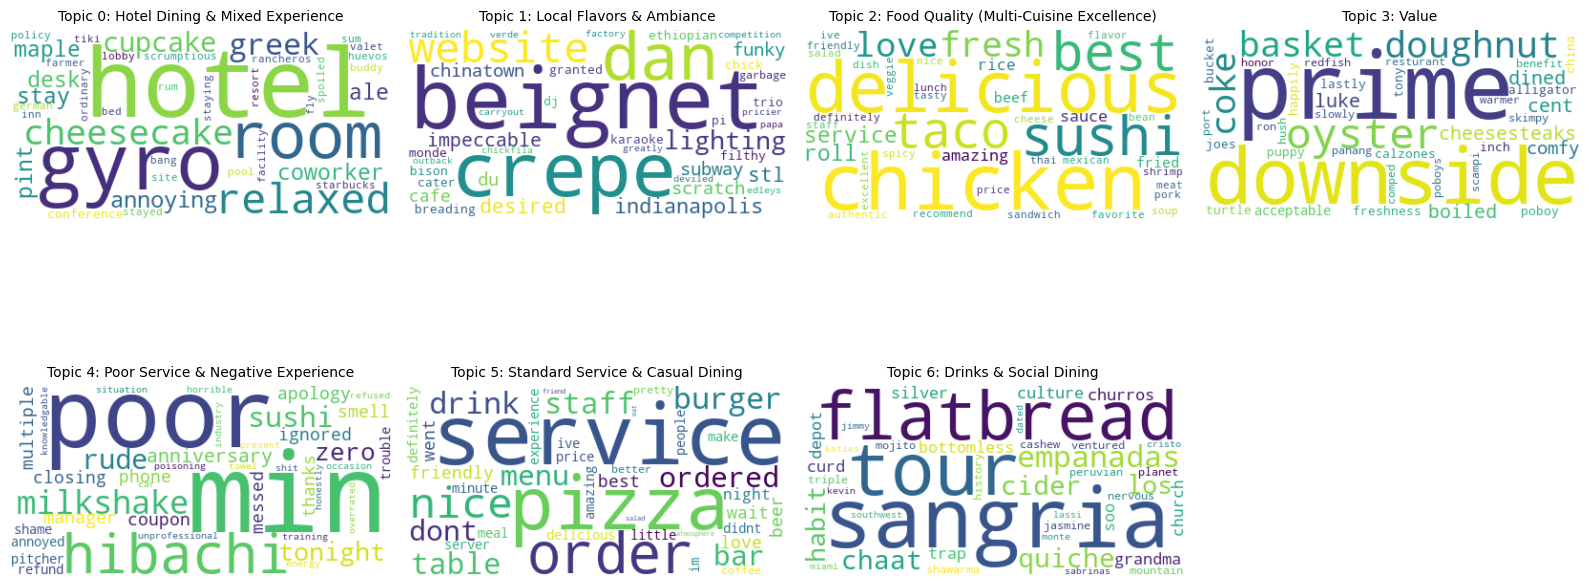

<Figure size 1000x600 with 0 Axes>

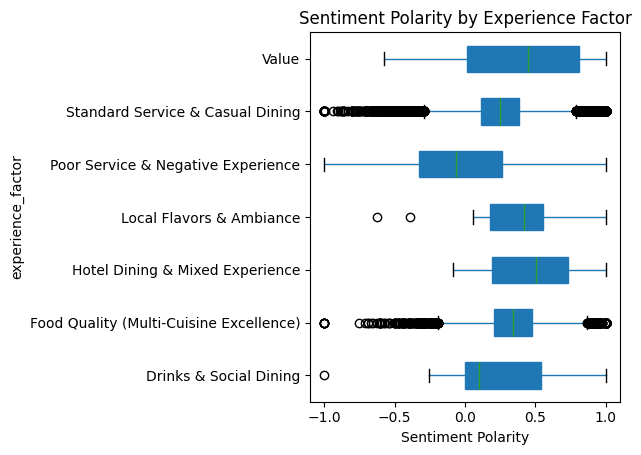

In [23]:
# Word clouds for each experience factor

from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Generate word clouds for each topic
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for topic_idx in range(best_n):
    word_freq = {tfidf_feature_names[i]: lda_tfidf.components_[topic_idx][i] 
                 for i in range(len(tfidf_feature_names))}
    wc = WordCloud(background_color='white', max_words=40, colormap='viridis')
    wc.generate_from_frequencies(word_freq)
    ax = axes[topic_idx]
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"Topic {topic_idx}: {topic_label_map.get(topic_idx, '')}", fontsize=10)
    ax.axis('off')

# Hide unused subplots if any
for j in range(best_n, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

# Boxplot: sentiment polarity by experience factor (dominant topic)
plt.figure(figsize=(10, 6))
df.boxplot(column='sentiment', by='experience_factor', vert=False, 
           patch_artist=True, grid=False)
plt.title('Sentiment Polarity by Experience Factor')
plt.suptitle('')
plt.xlabel('Sentiment Polarity')
plt.tight_layout()
plt.show()

In [24]:
# Re‑vectorize with stricter max_df to remove very common terms
tfidf_new = TfidfVectorizer(
    max_df=0.7,      # ignore terms appearing in >70% of reviews
    min_df=10,       # at least 10 reviews
    stop_words='english'
)
X_new = tfidf_new.fit_transform(df['clean_text_advanced'])
print("New TF-IDF matrix shape:", X_new.shape)

# Train LDA with sparse priors
n_topics_new = 5
lda_new = LatentDirichletAllocation(
    n_components=n_topics_new,
    doc_topic_prior=0.1,      # α: low value promotes sparsity
    topic_word_prior=0.05,    # η: low value sharpens word distributions
    random_state=42,
    max_iter=20,
    learning_method='online',
    batch_size=128,
)
lda_new.fit(X_new)

# Topic distribution per document
topic_dist_new = lda_new.transform(X_new)
df['dominant_topic_new'] = topic_dist_new.argmax(axis=1)

new_counts = df['dominant_topic_new'].value_counts()
print("New topic distribution (counts):")
print(new_counts)

feature_names_new = tfidf_new.get_feature_names_out()
topic_words_new = {}
print("\nNew Topic Top Words:")
for idx, topic in enumerate(lda_new.components_):
    top_indices = topic.argsort()[-10:][::-1]
    top_words = [feature_names_new[i] for i in top_indices]
    topic_words_new[idx] = top_words
    print(f"Topic {idx}: {' | '.join(top_words)}")

New TF-IDF matrix shape: (72125, 10487)
New topic distribution (counts):
dominant_topic_new
3    51714
0    20228
2       98
1       58
4       27
Name: count, dtype: int64

New Topic Top Words:
Topic 0: delicious | service | love | best | friendly | amazing | taco | fresh | staff | definitely
Topic 1: gyro | beignet | craft | santa | hibachi | ravioli | barbara | lost | cajun | relaxing
Topic 2: indian | hotel | tampa | room | chipotle | consistent | buffet | luke | naan | update
Topic 3: service | pizza | order | ordered | burger | table | dont | chicken | best | nice
Topic 4: donut | pho | bloody | mary | slider | dozen | hidden | mahi | bomb | roll


In [25]:
# Aspect‑based sentiment analysis using a pretrained BART model (zero‑shot)

from transformers import pipeline

aspect_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0
)


c:\Users\qym20\Programs\Python\Python_3_12_9\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 515/515 [00:00<00:00, 2839.36it/s]


In [26]:
aspects = ["food quality", "service", "ambiance", "price"]

def get_aspect_sentiments(text, aspects, classifier):
    results = {}
    for aspect in aspects:
        res = classifier(
            text,
            candidate_labels=["positive", "negative", "neutral"],
            hypothesis_template=f"The sentiment of this text about {aspect} is {{}}."
        )
        best_label = res['labels'][0]
        best_score = res['scores'][0]
        results[aspect] = (best_label, best_score)
    return results

sample_df = df.head(200).copy()

aspect_sentiments = []
for text in sample_df['text']:
    sent_dict = get_aspect_sentiments(text, aspects, aspect_classifier)
    aspect_sentiments.append(sent_dict)

for aspect in aspects:
    sample_df[f'{aspect}_sentiment'] = [asp[aspect][0] for asp in aspect_sentiments]
    sample_df[f'{aspect}_confidence'] = [asp[aspect][1] for asp in aspect_sentiments]

print(sample_df[['text'] + [f'{a}_sentiment' for a in aspects]].head())

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


                                                text food quality_sentiment  \
0  If you decide to eat here, just be aware it is...               negative   
1  Family diner. Had the buffet. Eclectic assortm...               positive   
2  Wow!  Yummy, different,  delicious.   Our favo...               positive   
3  Cute interior and owner (?) gave us tour of up...               positive   
4  I am a long term frequent customer of this est...               negative   

  service_sentiment ambiance_sentiment price_sentiment  
0          negative           negative        negative  
1          positive           positive        positive  
2          positive           positive        positive  
3          positive           positive        positive  
4          negative           negative        negative  


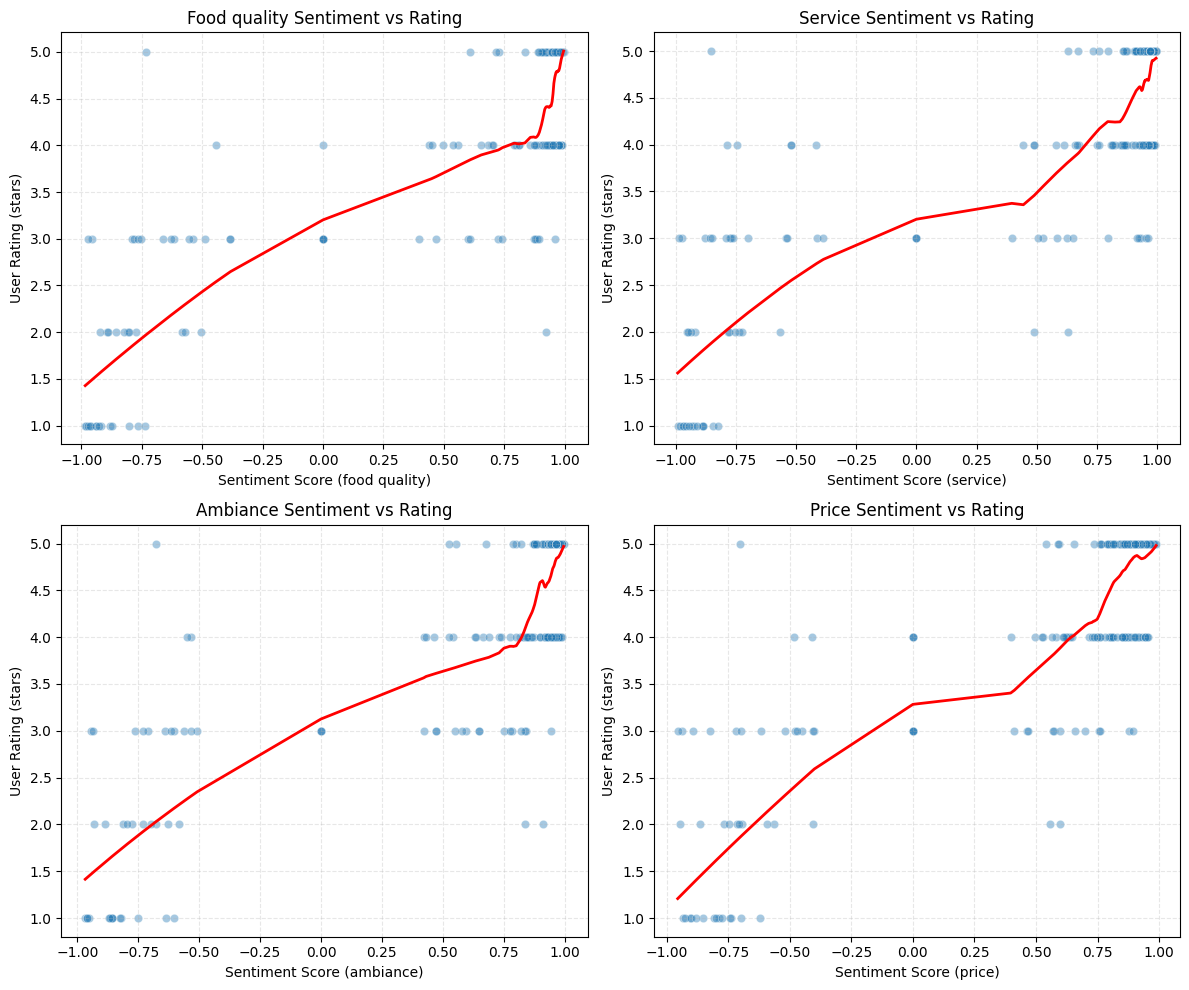

In [27]:
sentiment_to_num = {"positive": 1, "neutral": 0, "negative": -1}

# Create numeric sentiment directional scores multiplied by confidence
for aspect in aspects:
    sample_df[f'{aspect}_dir_score'] = sample_df.apply(
        lambda row: sentiment_to_num[row[f'{aspect}_sentiment']] * row[f'{aspect}_confidence'],
        axis=1
    )

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, aspect in enumerate(aspects):
    ax = axes[i]
    # Scatter plot: directional sentiment score vs. actual rating
    ax.scatter(sample_df[f'{aspect}_dir_score'], sample_df['stars_x'],
               alpha=0.4, edgecolors='w', linewidth=0.5)
    ax.set_xlabel(f'Sentiment Score ({aspect})')
    ax.set_ylabel('User Rating (stars)')
    ax.set_title(f'{aspect.capitalize()} Sentiment vs Rating')
    ax.grid(True, linestyle='--', alpha=0.3)

    from statsmodels.nonparametric.smoothers_lowess import lowess
    clean = sample_df[[f'{aspect}_dir_score', 'stars_x']].dropna()
    if len(clean) > 1:
        smooth = lowess(clean['stars_x'], clean[f'{aspect}_dir_score'], frac=0.3)
        ax.plot(smooth[:, 0], smooth[:, 1], color='red', linewidth=2)

plt.tight_layout()
plt.show()

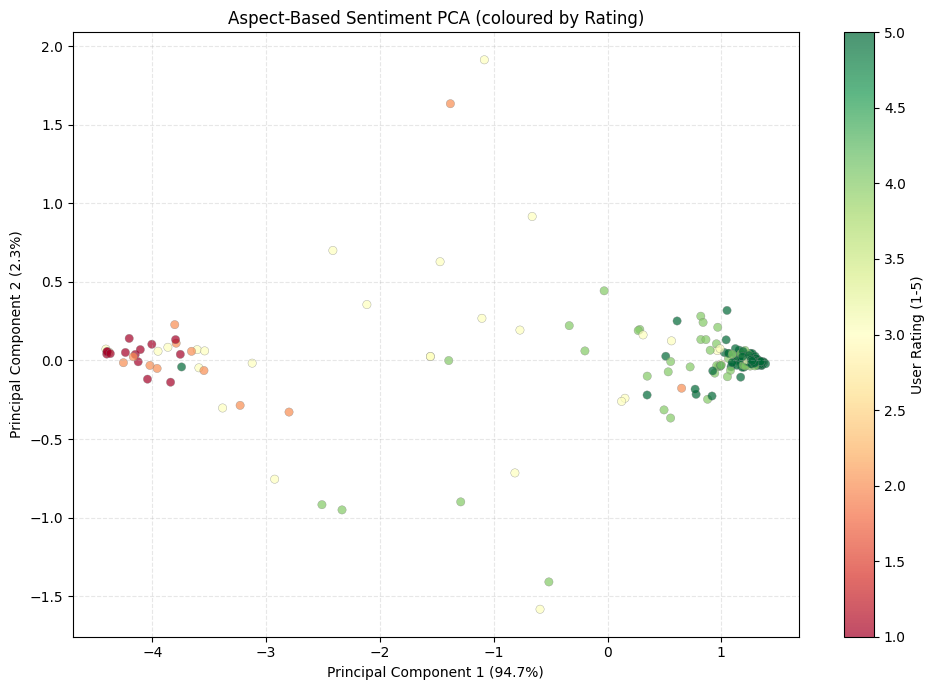

Explained variance ratio: [0.94722032 0.02306772]
Cumulative explained variance: 0.9702880445149464


In [28]:
from sklearn.decomposition import PCA

# Select the four aspect sentiment directional scores
score_cols = [f'{aspect}_dir_score' for aspect in aspects]
X_aspect = sample_df[score_cols].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_aspect)

# Fit PCA and transform to two components
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

# Add PCA results back to the relevant slice of sample_df
pca_df = X_aspect.copy()
pca_df['pc1'] = X_pca[:, 0]
pca_df['pc2'] = X_pca[:, 1]
pca_df['stars'] = sample_df.loc[X_aspect.index, 'stars_x']

# Plot the PCA scatter with colour representing star rating
plt.figure(figsize=(10, 7))
scatter = plt.scatter(
    pca_df['pc1'], pca_df['pc2'],
    c=pca_df['stars'], cmap='RdYlGn',
    alpha=0.7, edgecolors='grey', linewidth=0.3
)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.1%})')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.1%})')
plt.title('Aspect-Based Sentiment PCA (coloured by Rating)')
plt.colorbar(scatter, label='User Rating (1-5)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

# Print explained variance to assess how much information the first two PCs capture
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Cumulative explained variance:", pca.explained_variance_ratio_.sum())

In [ ]:
from sklearn.linear_model import LinearRegression

feature_aspects = ['food quality_dir_score', 'service_dir_score',
                   'ambiance_dir_score', 'price_dir_score']
X_aspect_full = sample_df[feature_aspects].dropna()
y_aspect_full = sample_df.loc[X_aspect_full.index, 'stars_x']

scaler_aspect = StandardScaler()
X_aspect_scaled = scaler_aspect.fit_transform(X_aspect_full)

aspect_lr = LinearRegression()
aspect_lr.fit(X_aspect_scaled, y_aspect_full)

print("Aspect-based linear model trained.")
print("Coefficients (standardised):")
for feat, coef in zip(feature_aspects, aspect_lr.coef_):
    print(f"  {feat}: {coef:.3f}")

def explain_review_with_aspects(review_index, df, scaler, model):
    row = df.iloc[review_index]
    
    # Extract the four aspect directional scores
    scores = {f: row[f] for f in feature_aspects}
    # Build a feature vector in the correct order
    X = np.array([[scores[f] for f in feature_aspects]])
    X_scaled = scaler.transform(X)
    predicted_rating = model.predict(X_scaled)[0]
    actual_rating = row['stars_x']
    
    # Compute contribution: coefficient * standardised value
    contrib = X_scaled[0] * model.coef_
    contrib_dict = dict(zip(feature_aspects, contrib))
    
    # Sort aspects by absolute contribution
    sorted_aspects = sorted(contrib_dict.items(), key=lambda x: abs(x[1]), reverse=True)
    
    # Generate explanation sentences
    print(f"\n--- Review Explanation (index {review_index}) ---")
    print(f"Actual rating: {actual_rating}")
    print(f"Predicted rating: {predicted_rating:.2f}")
    print("\nContribution of each experience aspect:")
    for aspect, value in sorted_aspects:
        aspect_name = aspect.replace('_dir_score', '').capitalize()
        direction = "positive" if value > 0 else "negative"
        print(f"- {aspect_name} had a {direction} influence "
              f"(weighted score: {value:.3f}).")
    
    # Additional commentary: overall sentiment and confidence summary
    print("\nDetailed aspect sentiments:")
    for aspect in ['food quality', 'service', 'ambiance', 'price']:
        label = row[f'{aspect}_sentiment']
        conf = row[f'{aspect}_confidence']
        print(f"- {aspect.capitalize()}: {label} (confidence: {conf:.2f})")
    
    # Overall textual summary
    dominant_pos = [a for a, v in contrib_dict.items() if v > 0.3]
    dominant_neg = [a for a, v in contrib_dict.items() if v < -0.3]
    summary = "Overall, this review "
    if len(dominant_pos) > len(dominant_neg):
        summary += "emphasises a very positive experience, especially regarding "
        summary += ", ".join([a.replace('_dir_score','') for a in dominant_pos[:2]])
    elif len(dominant_neg) > len(dominant_pos):
        summary += "expresses notable dissatisfaction, particularly with "
        summary += ", ".join([a.replace('_dir_score','') for a in dominant_neg[:2]])
    else:
        summary += "shows a mixed or neutral impression."
    print(f"\n{summary}")

explain_review_with_aspects(43, sample_df, scaler_aspect, aspect_lr)

Aspect-based linear model trained.
Coefficients (standardised):
  food quality_dir_score: 0.569
  service_dir_score: 0.138
  ambiance_dir_score: 0.099
  price_dir_score: 0.249

--- Review Explanation (index 43) ---
Actual rating: 4.0
Predicted rating: 4.51

Contribution of each experience aspect:
- Food quality had a positive influence (weighted score: 0.328).
- Price had a positive influence (weighted score: 0.124).
- Ambiance had a positive influence (weighted score: 0.047).
- Service had a positive influence (weighted score: 0.028).

Detailed aspect sentiments:
- Food quality: positive (confidence: 0.94)
- Service: positive (confidence: 0.66)
- Ambiance: positive (confidence: 0.87)
- Price: positive (confidence: 0.80)

Overall, this review emphasises a very positive experience, especially regarding food quality


c:\Users\qym20\Programs\Python\Python_3_12_9\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


In [33]:
explain_review_with_aspects(45, sample_df, scaler_aspect, aspect_lr)


--- Review Explanation (index 45) ---
Actual rating: 3.0
Predicted rating: 3.25

Contribution of each experience aspect:
- Food quality had a negative influence (weighted score: -0.445).
- Price had a negative influence (weighted score: -0.192).
- Service had a negative influence (weighted score: -0.098).
- Ambiance had a positive influence (weighted score: 0.006).

Detailed aspect sentiments:
- Food quality: neutral (confidence: 0.57)
- Service: neutral (confidence: 0.38)
- Ambiance: positive (confidence: 0.59)
- Price: neutral (confidence: 0.45)

Overall, this review expresses notable dissatisfaction, particularly with food quality


c:\Users\qym20\Programs\Python\Python_3_12_9\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
